# 2.0 Ttest — TVLA 누설 진단

## 이 노트북이 답하는 질문

**"이 구현에서 비밀에 의존하는 누설이 관측되는가?"**

`scalib.metrics.Ttest` 는 두 집단의 파형이 통계적으로 다른지를 시점마다 검정한다.
키를 복구하지 않는다 — **진단**이지 공격이 아니다.

| | |
|---|---|
| 입력 | `/tvla_rk` (랜덤 키 1,000장), `/tvla_fk` (고정 키 1,000장) — **평문은 두 집단 모두 동일 고정** |
| 하드웨어 | 불필요 |

## 시나리오

| 집단 | 키 | 평문 | 라벨 |
|------|----|------|:----:|
| 0 | 트레이스마다 **랜덤** | 고정 | 0 |
| 1 | **고정** | 같은 고정 평문 | 1 |

평문이 양쪽 모두 같으므로, 두 집단의 차이는 오직 **키가 고정인가 아닌가** 에서 온다.
비보호 구현이라면 키에 의존하는 중간값이 그대로 전력에 실리므로 차이가 나타난다.

## Welch t-test

시점 $j$ 에서

$$ t_j = \frac{\mu_{0,j} - \mu_{1,j}}{\sqrt{\dfrac{v_{0,j}}{n_0} + \dfrac{v_{1,j}}{n_1}}} $$

- $|t|$ 가 크다 = 두 집단의 평균이 우연이라고 보기 어려울 만큼 벌어져 있다
- 관례 경보선은 **±4.5**. 넘으면 "추가 조사 대상" 이지 **불합격 판정이 아니다**

## 차수

| 차수 | 보는 것 |
|:----:|---------|
| 1차 | 평균의 차이 |
| 2차 | 중심화 후 제곱의 평균 차이 — 평균이 같아도 **분산**이 다르면 잡힌다 |

`Ttest(d=2)` 는 둘을 한 번에 계산한다.

In [1]:
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# 공용 정의(AES 상수·데이터셋 로더)는 scalib_common.py 한 곳에만 둔다.
# 노트북마다 복사하면 값을 고칠 곳이 10군데가 되기 때문이다.
sys.path.insert(0, ".")
from scalib_common import SBOX, HW, AES_BLOCK, sbox_out, load_group, dataset_summary

import scalib
print("SCALib :", scalib.__version__)
print()
print(dataset_summary())

SCALib : 0.6.4

측정 조건
  created      2026-08-07T00:34:27
  cipher       AES-128-ECB (tiny-AES-c)
  platform     CW308_STM32F3
  ns           33172
  adc_mul      4
  adc_freq     29537976.0
  clk_hz       7384494.0
  gain_db      25.091743119266056
  trace_scale  32768.0

그룹
  /attack      10000 장 x 33172 샘플   키=fixed 평문=random
  /explore      5000 장 x 33172 샘플   키=random 평문=random
  /profiling  100000 장 x 33172 샘플   키=? 평문=?
  /tvla_fk      1000 장 x 33172 샘플   키=fixed 평문=fixed
  /tvla_rk      1000 장 x 33172 샘플   키=random 평문=fixed


In [2]:
rk = load_group("tvla_rk")
fk = load_group("tvla_fk")

print("집단 0 (random-key):", rk["t"].shape, " 키가 매번 다른가:", len(np.unique(rk["k"], axis=0)) > 1)
print("집단 1 (fixed-key) :", fk["t"].shape, " 키가 고정인가:", len(np.unique(fk["k"], axis=0)) == 1)
print("평문이 두 집단 모두 같은가:",
      np.array_equal(np.unique(rk["p"], axis=0), np.unique(fk["p"], axis=0)))

집단 0 (random-key): (1000, 33172)  키가 매번 다른가: True
집단 1 (fixed-key) : (1000, 33172)  키가 고정인가: True
평문이 두 집단 모두 같은가: True


---
## 1. `Ttest` API

| 단계 | 코드 |
|:----:|------|
| 생성 | `tt = Ttest(d=2)` |
| 누적 | `tt.fit_u(traces, x)` — 집단마다 한 번씩 불러도 되고, 합쳐서 한 번에 넣어도 된다 |
| 결과 | `tt.get_ttest()` → `(d, ns)` |

> **라벨 shape 규약이 API 마다 다르다.** 문서에 정리되어 있지 않고 실행해 봐야 알 수 있어
> 여기 적어 둔다. 틀리면 `ValueError: The classes array has N dimensions` 가 난다.
>
> | API | 라벨 shape | dtype |
> |-----|-----------|-------|
> | `Ttest` | `(n,)` | `uint16` |
> | `SNR`, `Cpa`, `MultiLDA` | `(n, nv)` | `uint16` |
> | `LDAClassifier` | `(n,)` | `uint16` |
> | `RLDAClassifier` | `(n, nv)` | `uint64` |
> | `RLDAInformationEstimator` | `(n,)` | `uint64` |
>
> 파형(`traces`)은 어디서나 `(n, ns)` `int16` 이다.


`Ttest` 의 라벨은 **1차원**이고 값은 **0 또는 1만** 쓴다. 그 밖의 정수는 shape 검사를
통과해도 내부에서 비정상 종료할 수 있다.

In [3]:
from scalib.metrics import Ttest
import time

n_rk, n_fk = rk["t"].shape[0], fk["t"].shape[0]
t0 = time.time()
ttest = Ttest(d=2)
ttest.fit_u(rk["t"], np.zeros(n_rk, dtype=np.uint16))   # 집단 0
ttest.fit_u(fk["t"], np.ones(n_fk, dtype=np.uint16))    # 집단 1
tt = ttest.get_ttest()
print("계산 %.1f 초 → %s  (차수, 샘플수)" % (time.time() - t0, tt.shape))

THRESHOLD = 4.5
for o in range(tt.shape[0]):
    a = np.abs(tt[o])
    print("  %d차: max|t| = %6.2f @ %6d,  |t|>%.1f 인 샘플 %d / %d (%.1f%%)"
          % (o + 1, a.max(), int(a.argmax()), THRESHOLD,
             int((a > THRESHOLD).sum()), tt.shape[1], 100 * (a > THRESHOLD).mean()))

계산 0.0 초 → (2, 33172)  (차수, 샘플수)
  1차: max|t| = 114.31 @   4145,  |t|>4.5 인 샘플 15662 / 33172 (47.2%)
  2차: max|t| =  15.40 @   3676,  |t|>4.5 인 샘플 6190 / 33172 (18.7%)


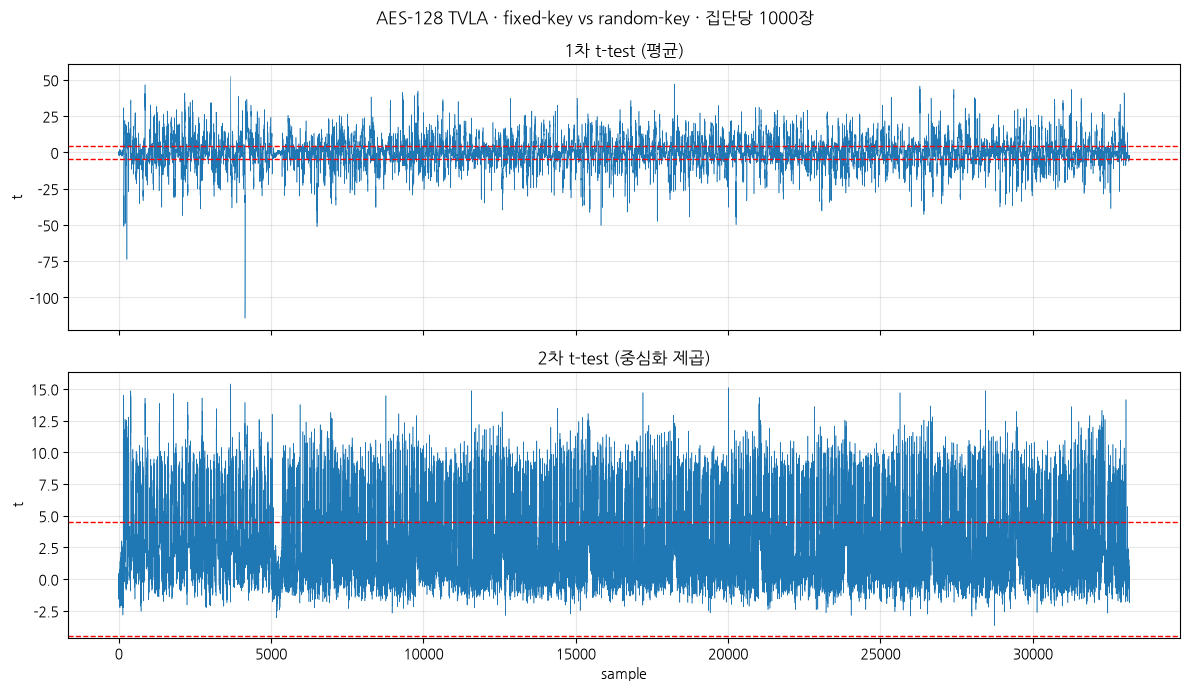

In [4]:
ns = tt.shape[1]
adc_mul = int(rk["attrs"]["adc_mul"])
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, o, title in zip(axes, (0, 1), ("1차 t-test (평균)", "2차 t-test (중심화 제곱)")):
    ax.plot(tt[o], lw=0.4, color="C0")
    ax.axhline(THRESHOLD, color="r", ls="--", lw=1)
    ax.axhline(-THRESHOLD, color="r", ls="--", lw=1)
    ax.set_ylabel("t"); ax.set_title(title); ax.grid(True, alpha=0.3)
axes[1].set_xlabel("sample")
fig.suptitle("AES-128 TVLA · fixed-key vs random-key · 집단당 %d장" % n_rk)
fig.tight_layout(); plt.show()

---
## 2. 어디서 새는가 — 파형 구조와 대조

파형은 **키 스케줄 + 10라운드** 전체를 담고 있다. `|t|` 봉우리가 어느 구간에 있는지 보면
누설이 키 스케줄에서 나오는지 라운드 연산에서 나오는지 짐작할 수 있다.

집단 0 은 키가 매번 바뀌므로 **키 스케줄 구간에서 특히 큰 차이**가 예상된다.

In [5]:
nseg = 10
seg = ns // nseg
print("구간(샘플)          사이클        1차 max|t|   2차 max|t|")
for s in range(nseg):
    a, b = s * seg, min((s + 1) * seg, ns)
    print("  %6d-%6d   %6d-%6d   %8.2f   %8.2f"
          % (a, b, a // adc_mul, b // adc_mul,
             np.abs(tt[0, a:b]).max(), np.abs(tt[1, a:b]).max()))

구간(샘플)          사이클        1차 max|t|   2차 max|t|
       0-  3317        0-   829      73.79      14.86
    3317-  6634      829-  1658     114.31      15.40
    6634-  9951     1658-  2487      42.29      14.47
    9951- 13268     2487-  3317      39.77      14.86
   13268- 16585     3317-  4146      50.40      13.49
   16585- 19902     4146-  4975      47.64      14.70
   19902- 23219     4975-  5804      49.91      15.10
   23219- 26536     5804-  6634      45.70      14.70
   26536- 29853     6634-  7463      43.47      14.85
   29853- 33170     7463-  8292      43.34      14.16


---
## 3. 몇 장이면 충분한가

`|t|` 는 트레이스 수가 늘면 커진다(분모의 표준오차가 $1/\sqrt{n}$ 로 줄기 때문).
따라서 **"몇 장에서 잰 $|t|$ 인가" 를 빼고 값만 말하는 것은 의미가 없다.**

In [6]:
print("집단당 장수    1차 max|t|   |t|>4.5 샘플 수")
for m in (50, 100, 250, 500, n_rk):
    tm = Ttest(d=2)
    tm.fit_u(rk["t"][:m], np.zeros(m, dtype=np.uint16))
    tm.fit_u(fk["t"][:m], np.ones(m, dtype=np.uint16))
    v = np.abs(tm.get_ttest()[0])
    print("   %6d       %8.2f    %8d" % (m, v.max(), int((v > 4.5).sum())))

집단당 장수    1차 max|t|   |t|>4.5 샘플 수
       50          21.09        2051
      100          30.97        3698
      250          49.85        7736
      500          77.21       12470
     1000         114.31       15662


### 주의 — `argmax` 위치는 안정적이지 않다

누설이 넓게 퍼져 있으면 최댓값을 내는 **위치**는 측정 잡음에 따라 바뀐다.
같은 장비·같은 배선에서 다시 재도 옮겨 다닌다. 비교할 때는 위치가 아니라
**크기**와 **임계 초과 샘플 수**를 본다.

In [7]:
a = np.abs(tt[0])
top = np.argsort(a)[::-1][:12]
print("1차 |t| 상위 12개 지점")
print("   위치        |t|")
for i in top:
    print("  %6d    %7.2f" % (i, a[i]))
print()
print("→ 상위 값들이 촘촘하면 1등의 위치는 우연이 정한다.")

1차 |t| 상위 12개 지점
   위치        |t|
    4145     114.31
    4147     113.86
    4146     111.17
    4148     105.18
    4149     101.99
    4144      83.27
     269      73.79
    4150      71.52
    4151      64.63
     268      57.34
    3673      52.32
    6509      51.35

→ 상위 값들이 촘촘하면 1등의 위치는 우연이 정한다.


---
## 4. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 두 집단 파형의 차이로 **누설 유무를 진단**한다 (키 복구 아님) |
| API | `Ttest(d)` → `fit_u(traces, x)` → `get_ttest()` → `(d, ns)` |
| `x` | `(n,)` `uint16`, 값은 **0/1만** |
| 임계 | \|t\|=4.5 는 관례 경보선. 넘으면 조사 대상이지 불합격 판정이 아니다 |
| 비교 기준 | max\|t\| **크기**와 임계 초과 샘플 수. **argmax 위치는 쓰지 않는다** |

### 실패 시 점검

1. 두 집단의 평문이 다르면 t 가 "키 차이" 가 아니라 "평문 차이" 를 가리킨다.
2. 집단 간 측정 조건(게인·트리거·샘플 수)이 다르면 그 차이가 그대로 t 로 나온다.
3. `|t|` 가 전 구간에서 작다 → 장수를 늘려 본다. 그래도 작으면 이 시나리오에서는
   관측되지 않는 것이며, **안전하다는 증명은 아니다.**

다음: `2.1.MTtest.ipynb` — 한 시점이 아니라 시점 **조합**을 보는 검정.